In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from matplotlib import dates

# Business Understanding:

Walmart is an American retail corporation that operates a chain of hypermarkets, discount department stores, and grocery stores.

# In this project, we focused to answer the following questions:

1. __Which store has minimum and maximum sales?__
2. __Which store has maximum standard deviation i.e., the sales vary a lot. Also, find out the coefficient of mean to standard deviation__
3. __Which store/s has good quarterly growth rate in Q3’2012__
4. __Some holidays have a negative impact on sales. Find out holidays which have higher sales than the mean sales in non-holiday season for all stores together__
5. __Provide a monthly and semester view of sales in units and give insights__
6. __Build prediction to forecast demand.__

# Data Understanding
There are sales data available for 45 stores of Walmart in Kaggle. This is the data that covers sales from 2010-02-05 to 2012-11-01.

The data contains these features:

1. __Store__ - the store number
2. __Date__ - the week of sales
3. __Weekly_Sales__ - sales for the given store
4. __Holiday_Flag__ - whether the week is a special holiday week 1 – Holiday week 0 – Non-holiday week
5. __Temperature__ - Temperature on the day of sale
6. __Fuel_Price__ - Cost of fuel in the region
7. __CPI__ – Prevailing consumer price index
8. __Unemployment__ - Prevailing unemployment rate

In [2]:
data  = pd.read_csv("Walmart_Store_sales.csv")
data.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   str    
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), str(1)
memory usage: 465.2 KB


# Data Preparation

In [5]:
data['Date'] = pd.to_datetime(data['Date'], dayfirst=True)
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[us]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
dtypes: datetime64[us](1), float64(5), int64(2)
memory usage: 402.3 KB


In [6]:
data.isnull().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

In [7]:
data['Day'] = pd.DatetimeIndex(data['Date']).day
data['Month'] = pd.DatetimeIndex(data['Date']).month
data['Year'] = pd.DatetimeIndex(data['Date']).year
data.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Day,Month,Year
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,5,2,2010
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,12,2,2010
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,19,2,2010
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,26,2,2010
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,5,3,2010


# Q1: Which store has minimum and maximum sales?

In [16]:
total_sales_for_each_store = data.groupby('Store')['Weekly_Sales'].sum().sort_values()
total_sales_for_each_store_ar = np.array(total_sales_for_each_store)
total_sales_for_each_store_ar

array([3.71602220e+07, 4.32930878e+07, 4.54756889e+07, 5.34122150e+07,
       5.51596264e+07, 5.75867351e+07, 6.27168851e+07, 7.42027403e+07,
       7.42524254e+07, 7.71415543e+07, 7.77892190e+07, 7.95657524e+07,
       8.15982751e+07, 8.91336839e+07, 9.05654354e+07, 1.01061179e+08,
       1.08117879e+08, 1.12395341e+08, 1.27782139e+08, 1.29951181e+08,
       1.31520672e+08, 1.37870310e+08, 1.38249763e+08, 1.43416394e+08,
       1.44287230e+08, 1.47075649e+08, 1.55114734e+08, 1.66819246e+08,
       1.81341935e+08, 1.89263681e+08, 1.93962787e+08, 1.94016021e+08,
       1.98750618e+08, 1.99613906e+08, 2.06634862e+08, 2.07445542e+08,
       2.22402809e+08, 2.23756131e+08, 2.53855917e+08, 2.71617714e+08,
       2.75382441e+08, 2.86517704e+08, 2.88999911e+08, 2.99543953e+08,
       3.01397792e+08])

In [17]:
clrs = ['lightsteelblue' if ((x < max(total_sales_for_each_store_ar)) and (x > min(total_sales_for_each_store_ar))) else 'midnightblue' for x in total_sales_for_each_store_ar]

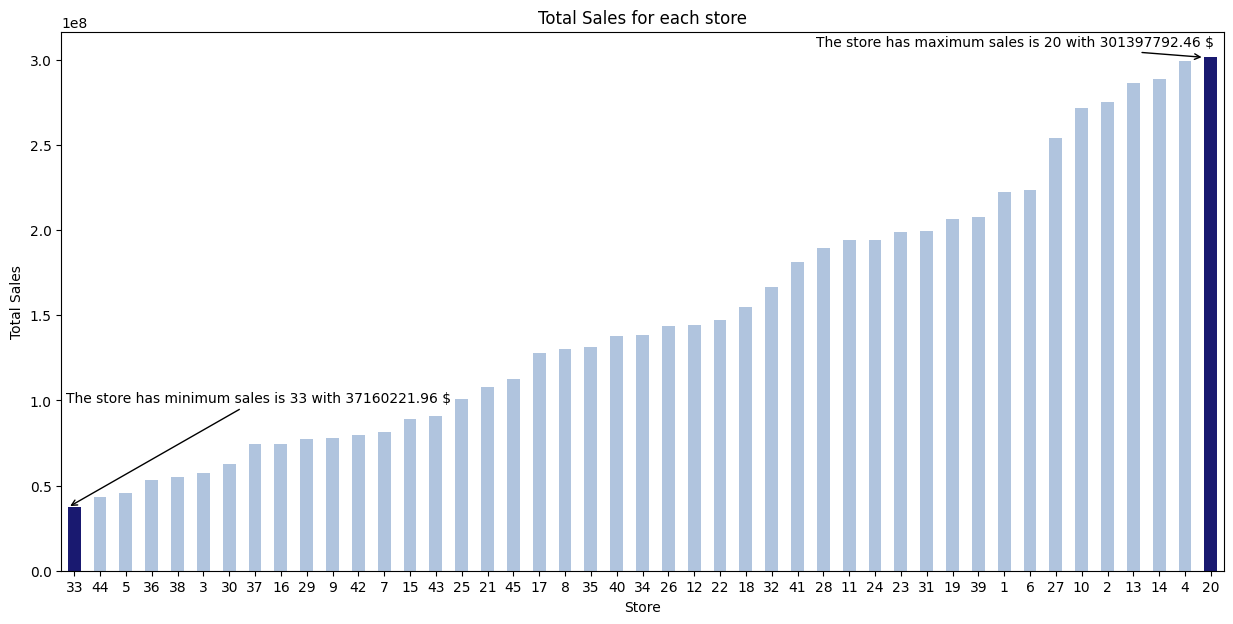

In [21]:
plt.figure(figsize=(15, 7))
ax = total_sales_for_each_store.plot(kind='bar', color=clrs)

p = ax.patches[0]
ax.annotate("The store has minimum sales is 33 with {0:.2f} $".format((p.get_height())), xy=(p.get_x(), p.get_height()), xycoords='data',
            xytext=(0.17, 0.32), textcoords='axes fraction',
            arrowprops=dict(arrowstyle="->", connectionstyle="arc3"),
            horizontalalignment='center', verticalalignment='center')

p = ax.patches[44]
ax.annotate("The store has maximum sales is 20 with {0:.2f} $".format((p.get_height())), xy=(p.get_x(), p.get_height()), xycoords='data',
            xytext=(0.82, 0.98), textcoords='axes fraction',
            arrowprops=dict(arrowstyle="->", connectionstyle="arc3"),
            horizontalalignment='center', verticalalignment='center')

plt.xticks(rotation=0)
plt.title("Total Sales for each store")
plt.xlabel('Store')
plt.ylabel('Total Sales')
plt.show()

# Q2: Which store has maximum standard deviation i.e., the sales vary a lot. Also, find out the coefficient of mean to standard deviation?

In [22]:
data_std = pd.DataFrame(data.groupby('Store')['Weekly_Sales'].std().sort_values(ascending=False))
data_std

,Weekly_Sales
Store,
14,317569.949476
10,302262.062504
20,275900.562742
4,266201.442297
13,265506.995776
23,249788.038068
27,239930.135688
2,237683.694682
39,217466.454833


/var/folders/0q/4dl3_14x1yl2gjrk08z4jp840000gn/T/ipykernel_8556/2820976747.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data[data['Store'] == data_std.head(1).index[0]]['Weekly_Sales'])


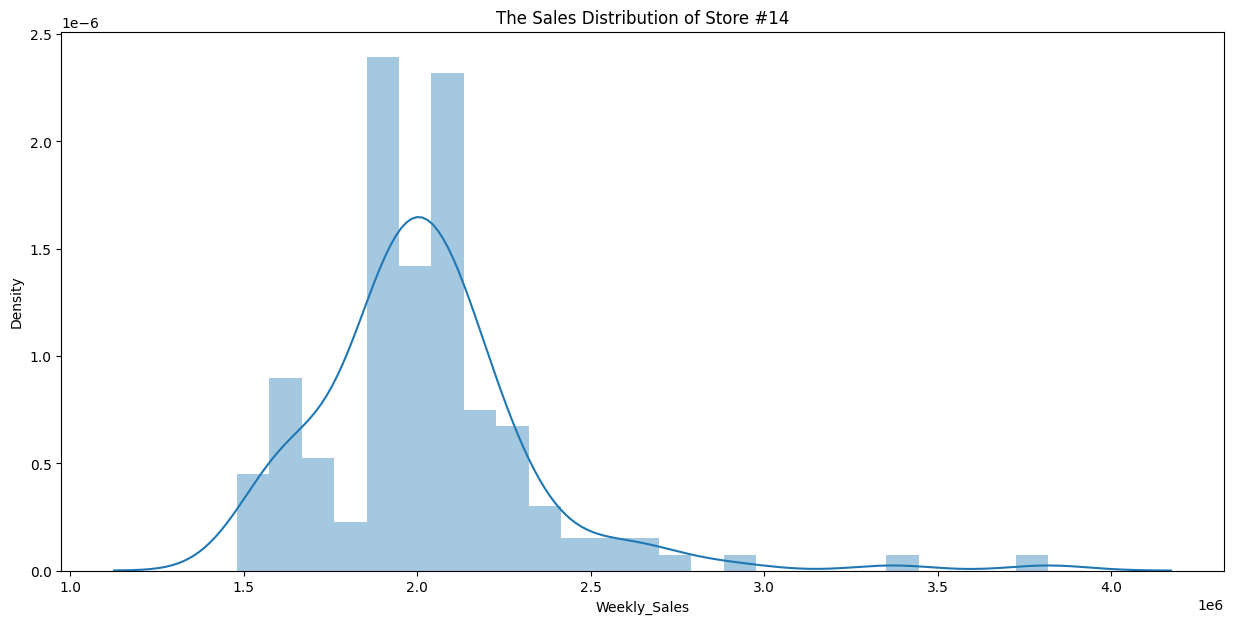

In [25]:
plt.figure(figsize=(15, 7))
sns.distplot(data[data['Store'] == data_std.head(1).index[0]]['Weekly_Sales'])
plt.title(f'The Sales Distribution of Store #{data_std.head(1).index[0]}')
plt.show()

In [26]:
coef_mean_std = pd.DataFrame(data.groupby('Store')['Weekly_Sales'].std() / data.groupby('Store')['Weekly_Sales'].mean())
coef_mean_std = coef_mean_std.rename(columns = {'Weekly_Sales' : 'Coefficient of mean to STD'})
coef_mean_std

,Coefficient of mean to STD
Store,
1,0.100292
2,0.123424
3,0.115021
4,0.127083
5,0.118668
6,0.135823
7,0.197305
8,0.116953
9,0.126895


/var/folders/0q/4dl3_14x1yl2gjrk08z4jp840000gn/T/ipykernel_8556/32965901.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data[data['Store'] == coef_mean_std_max.tail(1).index[0]]['Weekly_Sales'])


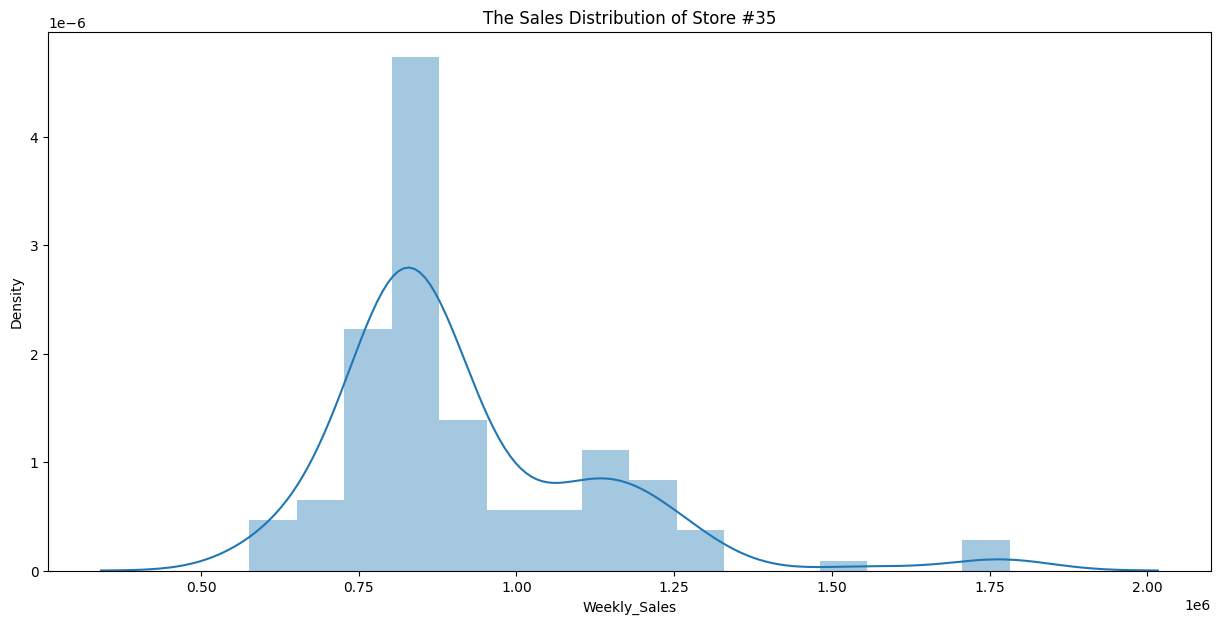

In [28]:
# Distribution of store has maximum coefficient of mean to standard deviation
coef_mean_std_max = coef_mean_std.sort_values(by='Coefficient of mean to STD')
plt.figure(figsize=(15,7))
sns.distplot(data[data['Store'] == coef_mean_std_max.tail(1).index[0]]['Weekly_Sales'])
plt.title('The Sales Distribution of Store #'+str(coef_mean_std_max.tail(1).index[0]));

# Q3: Which store/s has good quarterly growth rate in Q3’2012

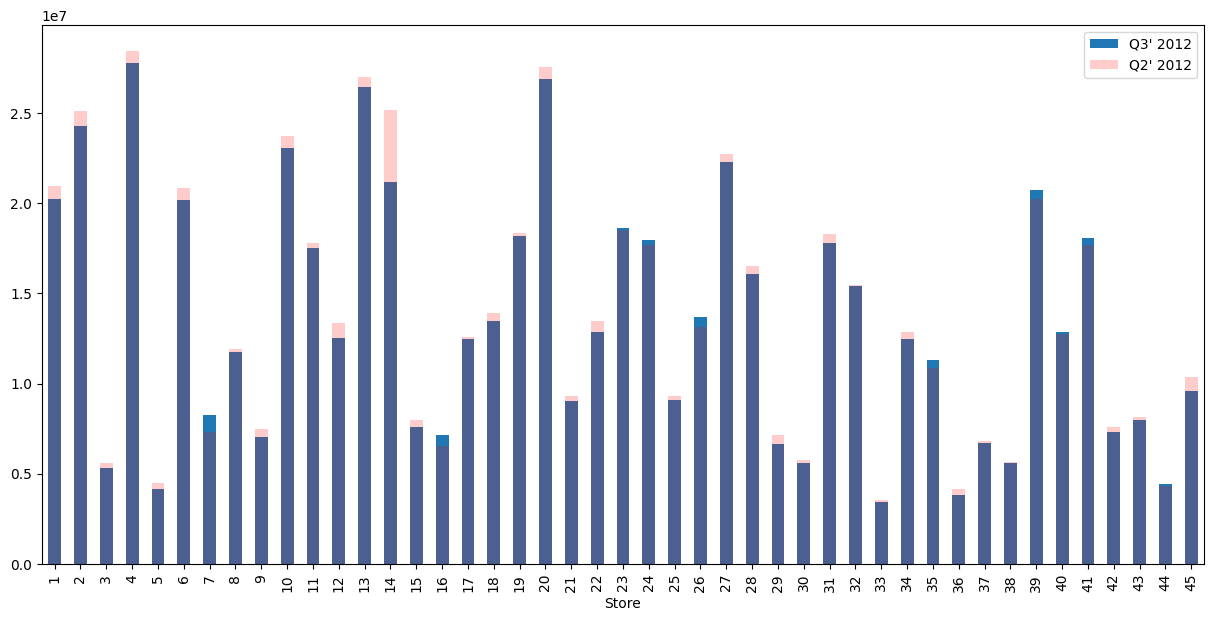

In [45]:
plt.figure(figsize=(15, 7))
Q3 = data[(data['Date'] > '2012-07-01') & (data['Date'] < '2012-09-30')].groupby('Store')['Weekly_Sales'].sum()
Q2 = data[(data['Date'] > '2012-04-01') & (data['Date'] < '2012-06-30')].groupby('Store')['Weekly_Sales'].sum()
Q2.plot(ax=Q3.plot(kind='bar',legend=True),kind='bar',color='r',alpha=0.2,legend=True);
plt.legend(["Q3' 2012", "Q2' 2012"])
plt.show()

In [35]:
Q2

Store
1     20978760.12
2     25083604.88
3      5620316.49
4     28454363.67
5      4466363.69
6     20833909.92
7      7290859.27
8     11919630.95
9      7484935.11
10    23750369.17
11    17787371.95
12    13362388.58
13    27009207.14
14    25155535.41
15     7955243.07
16     6564335.98
17    12592400.93
18    13896194.65
19    18367300.24
20    27524197.32
21     9294596.35
22    13487894.06
23    18488882.82
24    17684218.91
25     9323012.09
26    13155335.57
27    22744012.75
28    16506893.13
29     7125307.50
30     5742314.29
31    18267238.50
32    15489271.05
33     3549000.39
34    12853618.02
35    10838313.00
36     4151991.58
37     6824549.37
38     5637918.82
39    20214128.46
40    12727737.53
41    17659942.73
42     7568239.27
43     8168836.35
44     4306405.78
45    10390767.83
Name: Weekly_Sales, dtype: float64

# Q4: Some holidays have a negative impact on sales. Find out holidays which have higher sales than the mean sales in non-holiday season for all stores together

### Holiday Events:

* Super Bowl: 12-Feb-10, 11-Feb-11, 10-Feb-12, 8-Feb-13

* Labour Day: 10-Sep-10, 9-Sep-11, 7-Sep-12, 6-Sep-13

* Thanksgiving: 26-Nov-10, 25-Nov-11, 23-Nov-12, 29-Nov-13

* Christmas: 31-Dec-10, 30-Dec-11, 28-Dec-12, 27-Dec-13

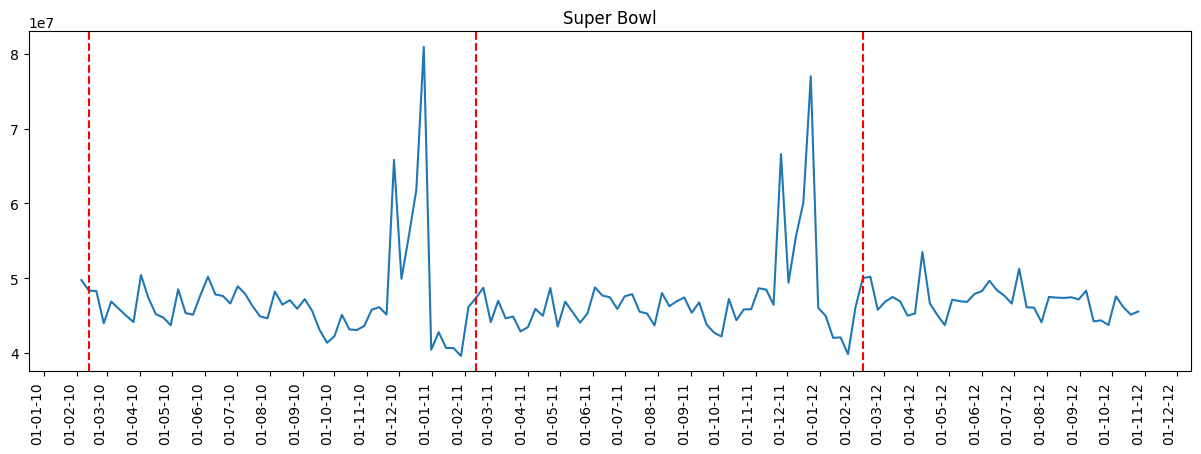

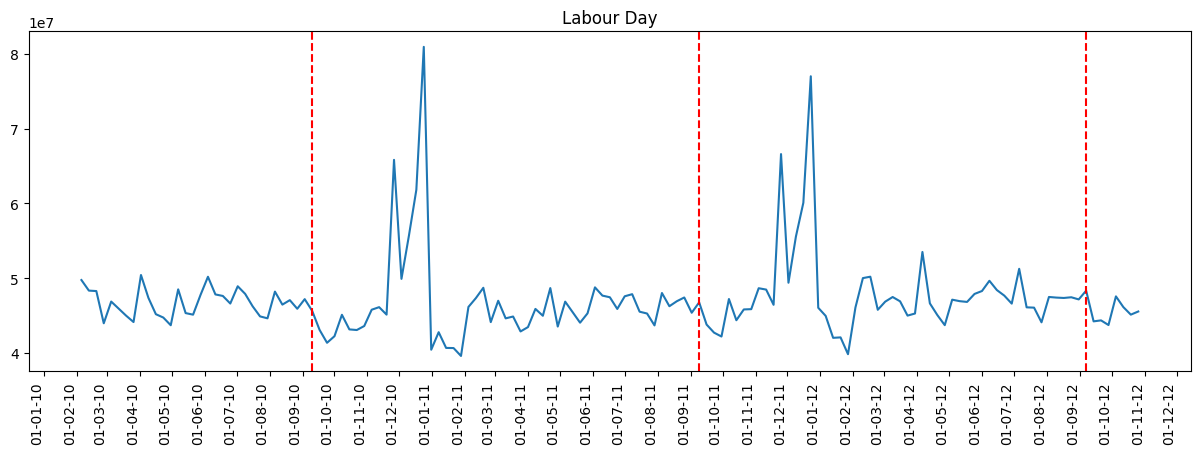

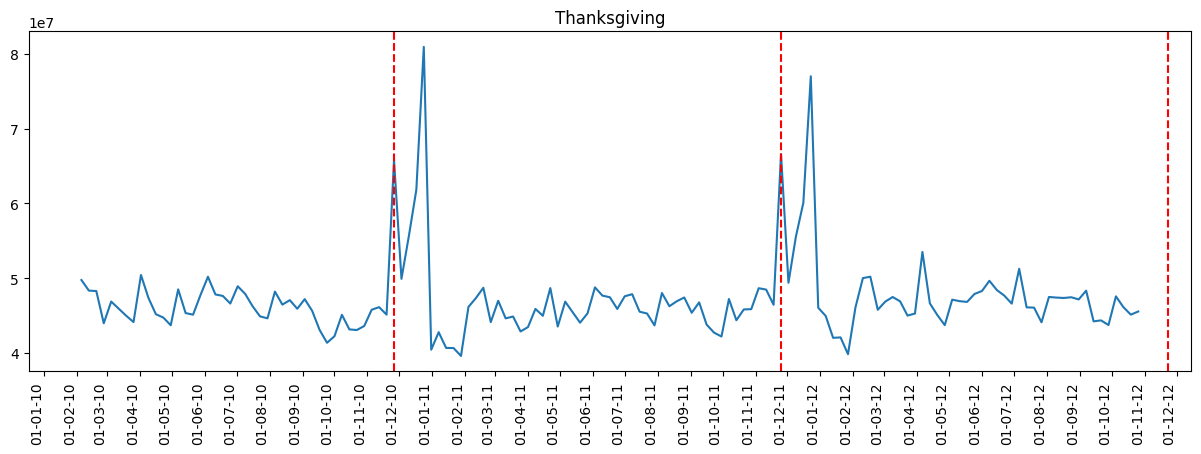

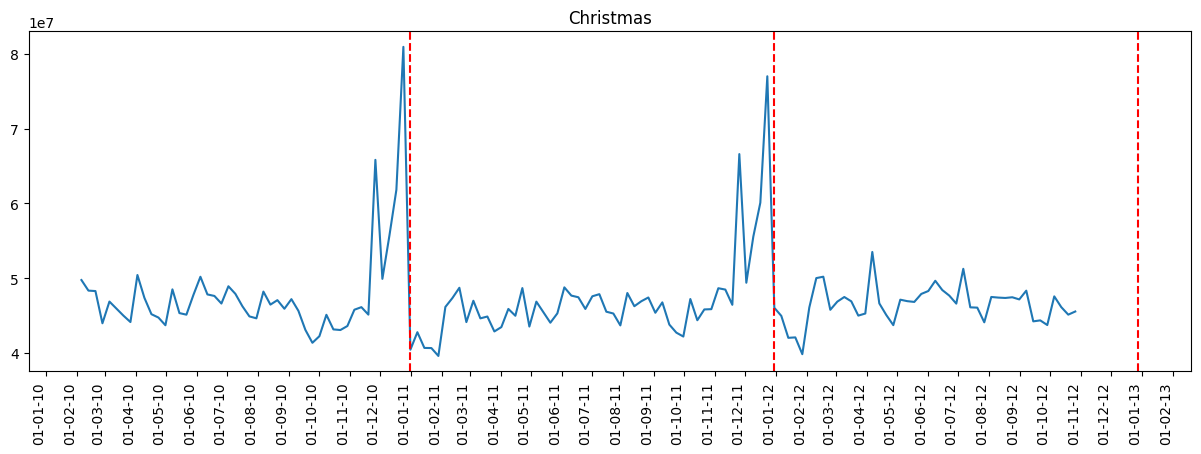

In [46]:
def plot_line(df, holiday_dates, holiday_label):
    fig, ax = plt.subplots(figsize = (15,5))  
    ax.plot(df['Date'],df['Weekly_Sales'],label=holiday_label)
    
    for day in holiday_dates:
        day = datetime.strptime(day, '%d-%m-%Y')
        plt.axvline(x=day, linestyle='--', c='r')
    

    plt.title(holiday_label)
    x_dates = df['Date'].dt.strftime('%Y-%m-%d').sort_values().unique()
    xfmt = dates.DateFormatter('%d-%m-%y')
    ax.xaxis.set_major_formatter(xfmt)
    ax.xaxis.set_major_locator(dates.DayLocator(1))
    plt.gcf().autofmt_xdate(rotation=90)
    plt.show()


total_sales = data.groupby('Date')['Weekly_Sales'].sum().reset_index()

Super_Bowl =['12-2-2010', '11-2-2011', '10-2-2012']

Labour_Day =  ['10-9-2010', '9-9-2011', '7-9-2012']

Thanksgiving =  ['26-11-2010', '25-11-2011', '23-11-2012']

Christmas = ['31-12-2010', '30-12-2011', '28-12-2012']
    
plot_line(total_sales,Super_Bowl,'Super Bowl')

plot_line(total_sales,Labour_Day,'Labour Day')

plot_line(total_sales,Thanksgiving,'Thanksgiving')

plot_line(total_sales,Christmas,'Christmas')